# 📧 Phishing Email Classification Pipeline

## Overview
This notebook implements an end-to-end machine learning pipeline for detecting phishing emails.
The system analyzes email text to classify messages as legitimate (safe) or phishing.

## 🎯 Objectives
- **Data Loading**: Load Phishing_Email.csv dataset
- **Data Cleaning**: Handle missing values, remove duplicates, advanced text preprocessing
- **Label Mapping**: Convert text labels to binary (Safe Email → 0, Phishing Email → 1)
- **Exploratory Analysis**: Generate word clouds showing distinctive terms for each class
- **Feature Engineering**: Transform email text using TF-IDF vectorization
- **Model Training**: Train SVM with Sigmoid Calibration
- **Model Evaluation**: Measure performance using cross-validation, test metrics, and stability analysis
- **Model Persistence**: Save the trained model and vectorizer

## 📊 Dataset
- **Source**: Phishing_Email.csv
- **Columns**: 
  - Email Text (raw email content with noise)
  - Email Type (Safe Email / Phishing Email)
- **Labels**: Binary (0 = Safe, 1 = Phishing)
- **Preprocessing**: Advanced text cleaning, noise removal, normalization, duplicate removal

## 🧹 Text Preprocessing
### Noise Reduction
- Remove label artifacts from text (e.g., "Safe Email1", "Phishing Email2")
- Fix spaced-out obfuscated words (e.g., "d i s c :" → "disc:")
- Normalize email headers (re:, fwd:)
- Remove excessive punctuation and asterisks
- Clean whitespace and special characters
- Remove very short emails (< 10 characters)

### Text Normalization
- Convert text to lowercase
- Normalize URLs and email addresses
- Remove excessive character repetition
- Strip leading/trailing special characters

## 🤖 Machine Learning Approach

### Feature Extraction
**TF-IDF Vectorization** converts email text into numerical features for machine learning models.

**Configuration:**
- **Max Features**: 10,000
- **N-grams**: Unigrams, Bigrams, Trigrams (1-3)
- **Min DF**: 2 (must appear in at least 2 documents)
- **Max DF**: 0.95 (exclude terms in >95% of documents)
- **Special Patterns**: URLs, email addresses

### Model Architecture
**Linear SVM with Sigmoid Calibration (CalibratedClassifierCV)**
- Base classifier: LinearSVC with 1000 max iterations
- Calibration: 5-fold cross-validation with sigmoid method
- Provides probability estimates for better classification decisions

### Evaluation Strategy
- **Training/Test Split**: 80/20 stratified split
- **10-fold Stratified Cross-Validation** on training data
- **Stability Analysis**: Testing across 10 different random splits
- **Metrics**: Accuracy, Precision, Recall, F1, ROC-AUC, Specificity
- **Visualizations**: Confusion matrix, classification report heatmap, word clouds

## 📦 Output Artifacts
- **tfidf_vectorizer.pkl** - Trained TF-IDF vectorizer
- **model.pkl** - Trained SVM classifier
- **wordclouds_comparison.png** - Distinctive terms visualization
- **ML_evaluation_metrics.png** - Performance metrics visualization

## 🔍 Key Features
- **Advanced Noise Handling**: Cleans heavily preprocessed and noisy email text
- **Distinctive Term Analysis**: Identifies words unique to safe vs phishing emails
- **High Performance**: Targets ~98% accuracy with consistent results
- **Speed Benchmarking**: Tracks training and prediction time
- **Production Ready**: Saves model artifacts for deployment

In [1]:
import pandas as pd
import time
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm import tqdm 
from wordcloud import WordCloud, STOPWORDS
from PIL import Image
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, average_precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
print("📁 Loading dataset...")
try:
    df = pd.read_csv("Phishing_Email.csv", engine="python", on_bad_lines="skip")
    print(f"✅ Loaded Phishing_Email.csv → {df.shape}")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")
    raise

# Display columns
print(f"\n📋 Columns in dataset: {list(df.columns)}")

# Drop the first column (email numbers/index)
print("\n🗑️ Dropping first column (email index)...")
df = df.iloc[:, 1:]  # Keep all columns except the first one
print(f"✅ Columns after dropping first: {list(df.columns)}")

# Display label distribution before mapping
print(f"\n🏷️ Original label distribution:")
print(df['Email Type'].value_counts())

# Map 'Safe Email' -> 0 and 'Phishing Email' -> 1
print("\n🔄 Mapping labels: 'Safe Email' -> 0, 'Phishing Email' -> 1")
label_mapping = {
    'Safe Email': 0,
    'Phishing Email': 1
}
df['Email Type'] = df['Email Type'].map(label_mapping)

# Check for any unmapped labels
unmapped = df[df['Email Type'].isna()]
if len(unmapped) > 0:
    print(f"⚠️ WARNING: Found {len(unmapped)} unmapped labels:")
    print(unmapped['Email Type'].value_counts())
    df = df.dropna(subset=['Email Type'])
    print(f"✅ Dropped unmapped labels")

# Convert to int
df['Email Type'] = df['Email Type'].astype(int)

# Display final label distribution
print(f"\n🏷️ Final label distribution:")
print(df['Email Type'].value_counts())

# Verify labels are only 0 and 1
unique_labels = df['Email Type'].unique()
print(f"\n✅ Unique labels in dataset: {sorted(unique_labels)}")

print(f"\n✅ Dataset loaded and prepared: {df.shape}")

📁 Loading dataset...
✅ Loaded Phishing_Email.csv → (20698, 3)

📋 Columns in dataset: ['Unnamed: 0', 'Email Text', 'Email Type']

🗑️ Dropping first column (email index)...
✅ Columns after dropping first: ['Email Text', 'Email Type']

🏷️ Original label distribution:
Email Type
Safe Email               11319
Phishing Email            7328
 nur ein Arbeitsloser        1
 penguins                    1
Name: count, dtype: int64

🔄 Mapping labels: 'Safe Email' -> 0, 'Phishing Email' -> 1
⚠️ WARNING: Found 2051 unmapped labels:
Series([], Name: count, dtype: int64)
✅ Dropped unmapped labels

🏷️ Final label distribution:
Email Type
0    11319
1     7328
Name: count, dtype: int64

✅ Unique labels in dataset: [np.int64(0), np.int64(1)]

✅ Dataset loaded and prepared: (18647, 2)


In [3]:
print("\n" + "="*80)
print("🧹 DATA CLEANING & PREPROCESSING")
print("="*80)

def clean_email_text(text):
    """Clean and normalize email text with noise reduction."""
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # Remove common email artifacts
    # Remove 'Safe Email' or 'Phishing Email' if they appear in text
    text = re.sub(r'Safe Email\d*|Phishing Email\d*', '', text, flags=re.IGNORECASE)
    
    # Fix spaced-out words (e.g., "d i s c : uniformitarianism" -> "disc: uniformitarianism")
    # Pattern: single letter followed by space, repeated
    text = re.sub(r'\b(\w)\s+:\s+', r'\1: ', text)
    
    # Remove excessive punctuation repetition
    text = re.sub(r'([^\w\s])\1{2,}', r'\1', text)
    
    # Fix common patterns like "re :" -> "re:"
    text = re.sub(r'\bre\s*:\s*', 're: ', text)
    text = re.sub(r'\bfwd\s*:\s*', 'fwd: ', text, flags=re.IGNORECASE)
    
    # Normalize asterisks around words (e.g., "* word *" -> "word")
    text = re.sub(r'\*\s*(\w+)\s*\*', r'\1', text)
    
    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text)
    
    # Normalize URLs
    text = re.sub(r'http\s+', 'http', text)
    text = re.sub(r'www\s+', 'www', text)
    
    # Remove excessive repeated characters (e.g., "hellooooo" -> "hello")
    text = re.sub(r'(.)\1{4,}', r'\1\1', text)
    
    # Remove leading/trailing whitespace and special characters
    text = text.strip()
    text = re.sub(r'^[^\w]+|[^\w]+$', '', text)
    
    return text

# Apply cleaning
print("🔧 Cleaning email text (this may take a moment)...")
df['Email Text'] = df['Email Text'].apply(clean_email_text)

# Remove empty emails
initial_count = len(df)
df = df[df['Email Text'].str.len() > 10]  # At least 10 characters
removed_empty = initial_count - len(df)
print(f"🗑️ Removed {removed_empty} empty or very short emails")

# Remove duplicates
initial_count = len(df)
df = df.drop_duplicates(subset=["Email Text"], keep="first")
removed_dupes = initial_count - len(df)
print(f"🗑️ Removed {removed_dupes} duplicate emails")

# Reset index
df = df.reset_index(drop=True)

print(f"\n📊 Final cleaned dataset: {df.shape}")
print(f"\n📊 Class distribution:")
print(df['Email Type'].value_counts())

print("\n✅ Cleaned dataset ready for model training")

print("\n" + "="*80)
print("📋 CLEANED DATASET PREVIEW")
print("="*80)

for idx in range(min(3, len(df))):
    row = df.iloc[idx]
    print(f"\n[Email {idx+1}]")
    print(f" Label: {row['Email Type']} ({'safe' if row['Email Type'] == 0 else 'phishing'})")
    print(f" Length: {len(row['Email Text'])} characters")
    print(f" Text: {row['Email Text'][:200]}...")
    print("-" * 80)

if len(df[df["Email Type"] == 0]) > 0:
    print("\n🟢 SAFE EMAIL EXAMPLE:")
    sample = df[df["Email Type"] == 0].iloc[0]
    print(sample['Email Text'][:500], "\n")

if len(df[df["Email Type"] == 1]) > 0:
    print("\n🔴 PHISHING EMAIL EXAMPLE:")
    sample = df[df["Email Type"] == 1].iloc[0]
    print(sample['Email Text'][:500], "\n")


🧹 DATA CLEANING & PREPROCESSING
🔧 Cleaning email text (this may take a moment)...
🗑️ Removed 558 empty or very short emails
🗑️ Removed 593 duplicate emails

📊 Final cleaned dataset: (17496, 2)

📊 Class distribution:
Email Type
0    10972
1     6524
Name: count, dtype: int64

✅ Cleaned dataset ready for model training

📋 CLEANED DATASET PREVIEW

[Email 1]
 Label: 0 (safe)
 Length: 1028 characters
 Text: re: 6 . 1100 , disc : uniformitarianism , re: 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am not sure that ...
--------------------------------------------------------------------------------

[Email 2]
 Label: 0 (safe)
 Length: 461 characters
 Text: the other side of galicismos galicismo is a spanish term which names the improper introduction of french words which are spanish sounding and thus very deceptive to the ear . galicismo is often consid...
---------------------------------------------

✅ Loaded mask images
🔍 Extracting class-specific terms...

✅ Top Safe Email Terms:
   enron: 16.7448
   ect: 4.4336
   hou ect: 2.5079
   vince: 2.0617
   ect ect: 2.0478
   hpl: 1.7675
   linguistics: 1.1077
   enron com: 1.1021
   rpm: 1.0244
   edu: 0.9182
   wrote: 0.7973
   language: 0.6583
   url http: 0.6412
   university: 0.5368
   hou: 0.4237

✅ Top Phishing Email Terms:
   click here: 1.4347
   adobe: 0.5125
   your: 0.4074
   save: 0.3726
   you: 0.2643
   here: 0.2350
   remove: 0.2092
   money: 0.1950
   online: 0.1926
   free: 0.1828
   removed: 0.1524
   low: 0.1411
   click: 0.1292
   professional: 0.1064
   offer: 0.1040

✅ Saved: ../pictures/wordclouds_comparison.png


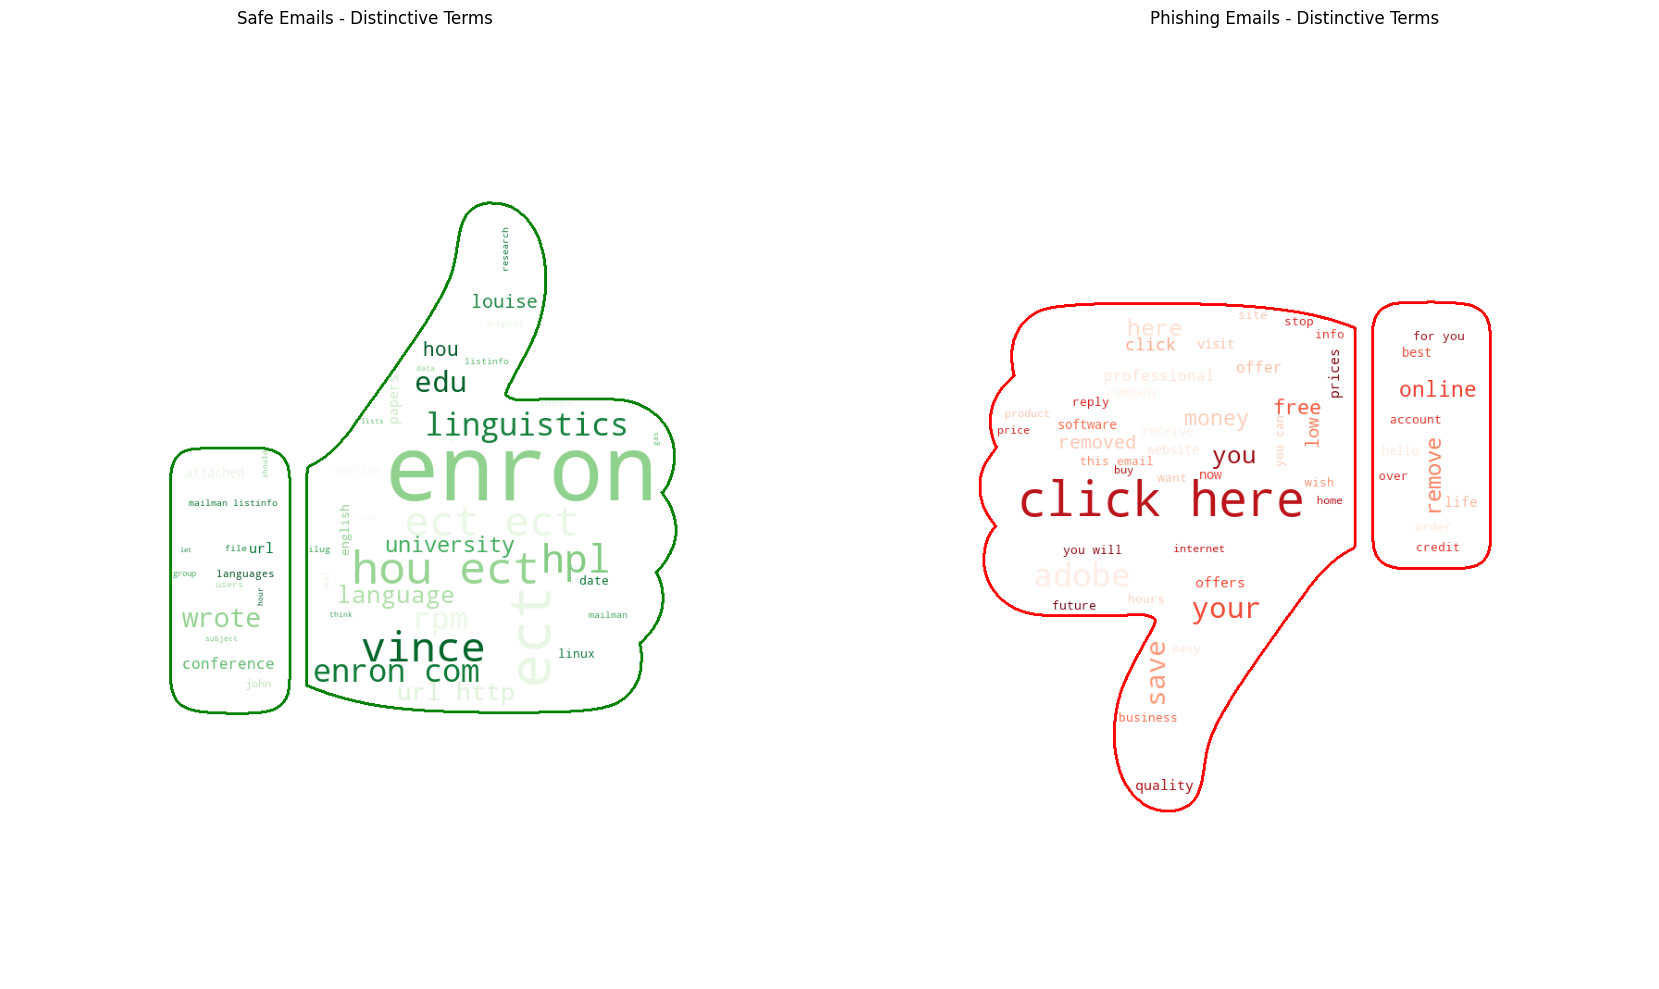

In [4]:
def load_mask(path):
    """Load and convert mask image."""
    mask = Image.open(path).convert("L")
    mask = mask.point(lambda x: 0 if x < 128 else 255, "L")
    return np.array(mask)

try:
    mask_up = load_mask("../pictures/thumbs-up.png")
    mask_down = load_mask("../pictures/thumbs-down.png")
    use_masks = True
    print("✅ Loaded mask images")
except:
    print("⚠️ Mask images missing → generating word clouds without masks")
    use_masks = False
    mask_up = None
    mask_down = None

print("🔍 Extracting class-specific terms...\n")

# Extended stopwords to filter common words
extended_stopwords = {
    'the', 'to', 'of', 'and', 'in', 'for', 'is', 'on', 'that', 'this', 
    'with', 'are', 'from', 'will', 'be', 'by', 'at', 'or', 'an', 'as',
    'was', 'has', 'have', 'had', 'been', 'can', 'may', 'would', 'could',
    'it', 'its', 'they', 'their', 'them', 'we', 'our', 'us', 'which',
    'all', 'any', 'some', 'more', 'not', 'but', 'if', 'when', 'than',
    'email', 'safe', 'phishing'
}

# Separate texts by class
safe_emails = df[df["Email Type"]==0]["Email Text"].values
phishing_emails = df[df["Email Type"]==1]["Email Text"].values

# Create vectorizer
tfidf_analyzer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    min_df=10,  # Must appear in at least 10 documents
    token_pattern=r'\b[a-zA-Z]{3,}\b'
)

# Fit on all data
tfidf_analyzer.fit(df["Email Text"].values)

# Transform each class separately
safe_vec = tfidf_analyzer.transform(safe_emails)
phishing_vec = tfidf_analyzer.transform(phishing_emails)

# Get mean TF-IDF scores for each class
safe_mean = safe_vec.mean(axis=0).A1
phishing_mean = phishing_vec.mean(axis=0).A1

feature_names = tfidf_analyzer.get_feature_names_out()

# Calculate ratio: how much more it appears in one class vs the other
epsilon = 0.0001

safe_ratio = safe_mean / (phishing_mean + epsilon)
phishing_ratio = phishing_mean / (safe_mean + epsilon)

# Filter and rank
safe_distinctive = {}
phishing_distinctive = {}

for i, term in enumerate(feature_names):
    # Skip if in stopwords or not alphabetic
    if term.lower() in extended_stopwords or not term.replace(' ', '').isalpha():
        continue
    
    # Only include if it appears meaningfully in the class
    if safe_mean[i] > 0.01 and safe_ratio[i] > 2.0:
        safe_distinctive[term] = safe_mean[i] * safe_ratio[i]
    
    if phishing_mean[i] > 0.01 and phishing_ratio[i] > 2.0:
        phishing_distinctive[term] = phishing_mean[i] * phishing_ratio[i]

print("✅ Top Safe Email Terms:")
for w, s in sorted(safe_distinctive.items(), key=lambda x: x[1], reverse=True)[:15]:
    print(f"   {w}: {s:.4f}")

print("\n✅ Top Phishing Email Terms:")
for w, s in sorted(phishing_distinctive.items(), key=lambda x: x[1], reverse=True)[:15]:
    print(f"   {w}: {s:.4f}")

# Use top terms for word clouds
safe_word_freq = dict(sorted(safe_distinctive.items(), key=lambda x: x[1], reverse=True)[:50])
phishing_word_freq = dict(sorted(phishing_distinctive.items(), key=lambda x: x[1], reverse=True)[:50])

wc_safe = WordCloud(
    width=800, height=800, background_color="white",
    mask=mask_up if use_masks else None,
    colormap="Greens", contour_color="green",
    contour_width=3, relative_scaling=0.5
).generate_from_frequencies(safe_word_freq)

wc_phishing = WordCloud(
    width=800, height=800, background_color="white",
    mask=mask_down if use_masks else None,
    colormap="Reds", contour_color="red",
    contour_width=3, relative_scaling=0.5
).generate_from_frequencies(phishing_word_freq)

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(wc_safe); ax[0].axis("off")
ax[0].set_title("Safe Emails - Distinctive Terms")

ax[1].imshow(wc_phishing); ax[1].axis("off")
ax[1].set_title("Phishing Emails - Distinctive Terms")

plt.tight_layout()
plt.savefig("../pictures/wordclouds_comparison.png", dpi=300, bbox_inches='tight', facecolor='white')
print("\n✅ Saved: ../pictures/wordclouds_comparison.png")
plt.show()

In [5]:
X_text = df["Email Text"]
y = df["Email Type"].values

print("🔧 Creating TF-IDF vectorizer...")
tfidf = TfidfVectorizer(
    lowercase=True,
    max_features=10000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    token_pattern=r'(?u)\b\w+\b|https?://\S+|www\.\S+|\S+@\S+',
    strip_accents='unicode',
    analyzer='word'
)

print("\n✅ TF-IDF vectorizer created (not fitted yet)")

# Split the data into train and test sets
print("\n🔀 Splitting data into train (80%) and test (20%) sets...")
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\n📊 Dataset split:")
print(f"   Training samples: {len(X_train_text):,}")
print(f"   Testing samples: {len(X_test_text):,}")
print(f"\n   Training label distribution:")
print(pd.Series(y_train).value_counts())
print(f"\n   Testing label distribution:")
print(pd.Series(y_test).value_counts())

🔧 Creating TF-IDF vectorizer...

✅ TF-IDF vectorizer created (not fitted yet)

🔀 Splitting data into train (80%) and test (20%) sets...

📊 Dataset split:
   Training samples: 13,996
   Testing samples: 3,500

   Training label distribution:
0    8777
1    5219
Name: count, dtype: int64

   Testing label distribution:
0    2195
1    1305
Name: count, dtype: int64


In [6]:
print("\n" + "="*60)
print("🔧 TF-IDF VECTORIZATION")
print("="*60)

# Fit TF-IDF on training data only
print("\n🔧 Fitting TF-IDF on training data...")
x_train = tfidf.fit_transform(X_train_text)
x_test = tfidf.transform(X_test_text)  # Only transform test data

print(f"\n✅ TF-IDF Complete:")
print(f"   Features: {x_train.shape[1]:,}")
print(f"   Training samples: {x_train.shape[0]:,}")
print(f"   Test samples: {x_test.shape[0]:,}")
print(f"   Training sparsity: {(1 - x_train.nnz / (x_train.shape[0] * x_train.shape[1])) * 100:.2f}%")
print(f"   Test sparsity: {(1 - x_test.nnz / (x_test.shape[0] * x_test.shape[1])) * 100:.2f}%")

# Cross-validation setup
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Model - SVM with Sigmoid Calibration
print("\n" + "="*60)
print("MODEL TRAINING - SVM with Sigmoid Calibration")
print("="*60)

base_svm = LinearSVC(random_state=42, max_iter=1000)
model = CalibratedClassifierCV(base_svm, cv=5, method="sigmoid")

# Cross-validation on training data
print("\n🔧 Running 10-fold cross-validation on training data...")
scores_cv = cross_val_score(model, x_train, y_train, cv=cv, scoring="f1")

print(f"\n📊 Cross-Validation F1: {scores_cv.mean():.4f}")
print(f"   Std Dev: {scores_cv.std():.4f}")

# Fit on training data with timing
print("\n🔧 Training final model on training set...")
start_train = time.perf_counter()
model.fit(x_train, y_train)
train_time = time.perf_counter() - start_train

# Evaluate on test data with timing
print("\n🔧 Evaluating on test set...")
start_pred = time.perf_counter()
y_pred = model.predict(x_test)
pred_time = time.perf_counter() - start_pred

print(f"\n⏱️ Timing:")
print(f"   Training time: {train_time:.4f} seconds")
print(f"   Prediction time: {pred_time:.4f} seconds")
print(f"   Prediction speed: {x_test.shape[0]/pred_time:.0f} samples/second")

print(f"\n📊 Test Set Performance:")
print(f"   F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"   Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred):.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Safe", "Phishing"]))

# Save the vectorizer and model
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(model, "model.pkl")
print("\n✅ Saved: tfidf_vectorizer.pkl")
print("✅ Saved: model.pkl")


🔧 TF-IDF VECTORIZATION

🔧 Fitting TF-IDF on training data...

✅ TF-IDF Complete:
   Features: 10,000
   Training samples: 13,996
   Test samples: 3,500
   Training sparsity: 98.20%
   Test sparsity: 98.25%

MODEL TRAINING - SVM with Sigmoid Calibration

🔧 Running 10-fold cross-validation on training data...

📊 Cross-Validation F1: 0.9809
   Std Dev: 0.0046

🔧 Training final model on training set...

🔧 Evaluating on test set...

⏱️ Timing:
   Training time: 1.8898 seconds
   Prediction time: 0.0192 seconds
   Prediction speed: 182368 samples/second

📊 Test Set Performance:
   F1 Score: 0.9781
   Accuracy: 0.9837
   Precision: 0.9800
   Recall: 0.9762

📋 Classification Report:
              precision    recall  f1-score   support

        Safe       0.99      0.99      0.99      2195
    Phishing       0.98      0.98      0.98      1305

    accuracy                           0.98      3500
   macro avg       0.98      0.98      0.98      3500
weighted avg       0.98      0.98      0.98

In [7]:
print("\n" + "="*60)
print("🎲 MODEL STABILITY ANALYSIS")
print("="*60)
print("Evaluating model across 10 different random splits...\n")

seeds = np.arange(10)
accuracies = []
f1_scores_list = []
precision_scores_list = []
recall_scores_list = []

for seed in tqdm(seeds, desc="Running experiments", ncols=80):
    # Split with different random seed
    x_tr_text, x_te_text, y_tr, y_te = train_test_split(
        X_text, y, test_size=0.2, stratify=y, random_state=seed
    )
    
    # Create vectorizer
    tfidf_temp = TfidfVectorizer(
        lowercase=True,
        max_features=10000,
        ngram_range=(1, 3),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        token_pattern=r'(?u)\b\w+\b|https?://\S+|www\.\S+|\S+@\S+',
        strip_accents='unicode',
        analyzer='word'
    )
    
    x_tr = tfidf_temp.fit_transform(x_tr_text)
    x_te = tfidf_temp.transform(x_te_text)
    
    # Train and evaluate
    base_svm_temp = LinearSVC(random_state=42, max_iter=1000)
    model_temp = CalibratedClassifierCV(base_svm_temp, cv=5, method="sigmoid")
    model_temp.fit(x_tr, y_tr)
    y_pred = model_temp.predict(x_te)
    
    # Calculate metrics
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    precision = precision_score(y_te, y_pred)
    recall = recall_score(y_te, y_pred)
    
    accuracies.append(acc)
    f1_scores_list.append(f1)
    precision_scores_list.append(precision)
    recall_scores_list.append(recall)

print("\n✅ Stability Analysis Complete!\n")
print(f"{'Seed':<8} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12}")
print("-" * 60)
for i, seed in enumerate(seeds):
    print(f"{seed:<8} {accuracies[i]:<12.4f} {precision_scores_list[i]:<12.4f} {recall_scores_list[i]:<12.4f} {f1_scores_list[i]:<12.4f}")

print("\n" + "="*60)
print("📈 STABILITY SUMMARY")
print("="*60)
print(f"Accuracy:  {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Precision: {np.mean(precision_scores_list):.4f} ± {np.std(precision_scores_list):.4f}")
print(f"Recall:    {np.mean(recall_scores_list):.4f} ± {np.std(recall_scores_list):.4f}")
print(f"F1 Score:  {np.mean(f1_scores_list):.4f} ± {np.std(f1_scores_list):.4f}")
print("="*60)


🎲 MODEL STABILITY ANALYSIS
Evaluating model across 10 different random splits...



Running experiments: 100%|██████████████████████| 10/10 [05:52<00:00, 35.22s/it]


✅ Stability Analysis Complete!

Seed     Accuracy     Precision    Recall       F1 Score    
------------------------------------------------------------
0        0.9880       0.9839       0.9839       0.9839      
1        0.9849       0.9793       0.9801       0.9797      
2        0.9877       0.9839       0.9831       0.9835      
3        0.9820       0.9770       0.9747       0.9758      
4        0.9866       0.9838       0.9801       0.9820      
5        0.9837       0.9815       0.9747       0.9781      
6        0.9826       0.9785       0.9747       0.9766      
7        0.9854       0.9779       0.9831       0.9805      
8        0.9854       0.9801       0.9808       0.9805      
9        0.9877       0.9839       0.9831       0.9835      

📈 STABILITY SUMMARY
Accuracy:  0.9854 ± 0.0020
Precision: 0.9810 ± 0.0026
Recall:    0.9798 ± 0.0036
F1 Score:  0.9804 ± 0.0027


✅ Saved: ../pictures/ML_evaluation_metrics.png


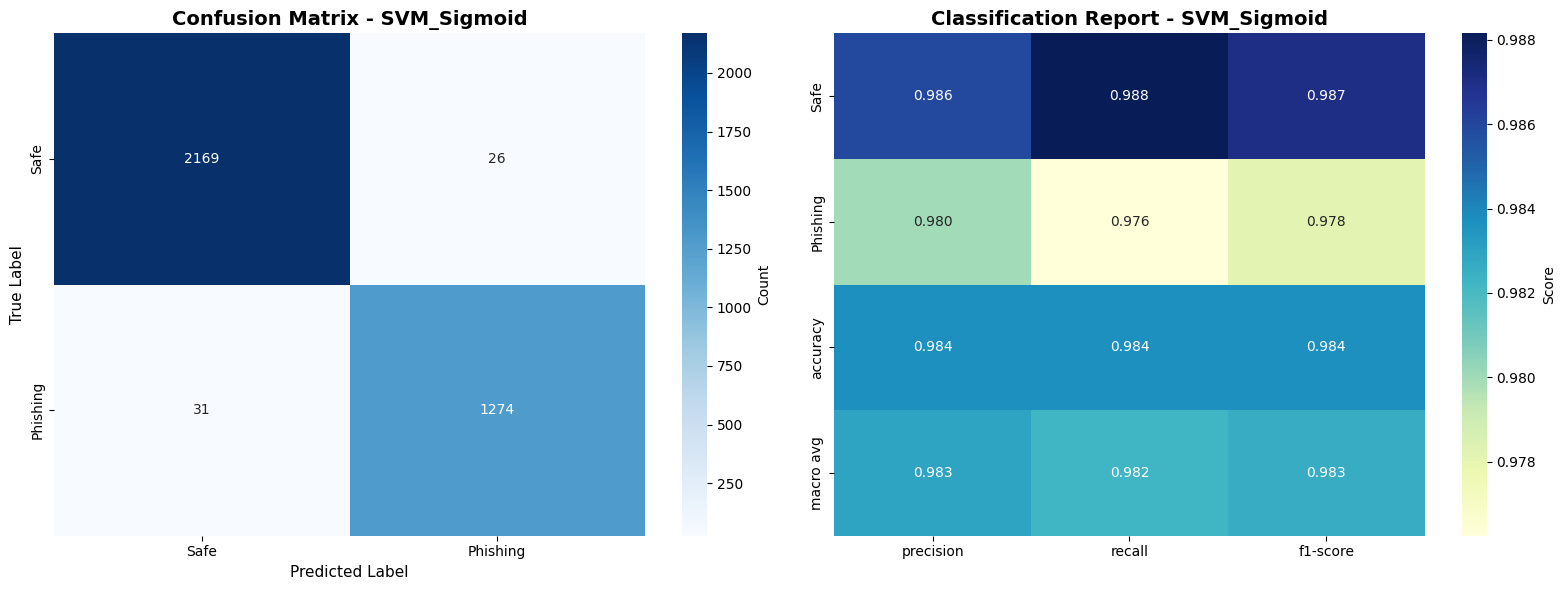


🎯 DETAILED TEST SET METRICS

Model: SVM_Sigmoid

📊 Performance Metrics:
   Accuracy:  0.9837
   Precision: 0.9800
   Recall:    0.9762
   F1 Score:  0.9781
   ROC-AUC:   0.9986
   Avg Precision: 0.9977

📋 Confusion Matrix:
   True Negatives:  2,169
   False Positives: 26
   False Negatives: 31
   True Positives:  1,274

🎯 Additional Metrics:
   Specificity: 0.9882
   False Positive Rate: 0.0118
   False Negative Rate: 0.0238


In [8]:
y_pred = model.predict(x_test)

# Get probabilities for metrics
if hasattr(model, "predict_proba"):
    y_proba = model.predict_proba(x_test)[:, 1]
elif hasattr(model, "decision_function"):
    y_proba = model.decision_function(x_test)
else:
    y_proba = None

# Create a figure with 2 subplots
fig = plt.figure(figsize=(16, 6))

# 1. Confusion Matrix
ax1 = plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Safe", "Phishing"], 
            yticklabels=["Safe", "Phishing"],
            cbar_kws={"label": "Count"}, ax=ax1)
ax1.set_title("Confusion Matrix - SVM_Sigmoid", fontsize=14, fontweight="bold")
ax1.set_ylabel("True Label", fontsize=11)
ax1.set_xlabel("Predicted Label", fontsize=11)

# 2. Classification Report Heatmap
ax2 = plt.subplot(1, 2, 2)
report = classification_report(y_test, y_pred, 
                               target_names=["Safe", "Phishing"], 
                               output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :-1].T
sns.heatmap(report_df, annot=True, fmt=".3f", cmap="YlGnBu", 
            cbar_kws={"label": "Score"}, ax=ax2)
ax2.set_title("Classification Report - SVM_Sigmoid", fontsize=14, fontweight="bold")

plt.tight_layout()
fig.savefig("../pictures/ML_evaluation_metrics.png", dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Saved: ../pictures/ML_evaluation_metrics.png")
plt.show()

# Print detailed metrics
print("\n" + "="*60)
print("🎯 DETAILED TEST SET METRICS")
print("="*60)
print(f"\nModel: SVM_Sigmoid")
print(f"\n📊 Performance Metrics:")
print(f"   Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred):.4f}")
print(f"   Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"   F1 Score:  {f1_score(y_test, y_pred):.4f}")

if y_proba is not None:
    print(f"   ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
    print(f"   Avg Precision: {average_precision_score(y_test, y_proba):.4f}")

print(f"\n📋 Confusion Matrix:")
print(f"   True Negatives:  {cm[0, 0]:,}")
print(f"   False Positives: {cm[0, 1]:,}")
print(f"   False Negatives: {cm[1, 0]:,}")
print(f"   True Positives:  {cm[1, 1]:,}")

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print(f"\n🎯 Additional Metrics:")
print(f"   Specificity: {specificity:.4f}")
print(f"   False Positive Rate: {fp / (fp + tn):.4f}")
print(f"   False Negative Rate: {fn / (fn + tp):.4f}")
print("="*60)